# Trabajo Final de Machine Learning - Ejercicio 2
## Clasificacion: contratacion de deposito a plazo

**Grupo:** F
**Integrantes:**
- Alexis Gonzalez
- Luis Morales
- Alexia Orce
- Georgina Sicco
- Emiliano Prockoff

Se predice si un cliente suscribira (`yes`) o no (`no`) un deposito bancario a largo plazo.

## 1. Metadata y planteamiento

El dataset Bank Marketing registra campanas telefonicas de una institucion bancaria. La variable objetivo es `y`. Se utiliza `bank-full.csv`, disponible dentro de `bank.zip`, con separador punto y coma.

Como existe desbalance de clases, se reportan precision, recall, F1, ROC-AUC y matriz de confusion, ademas de accuracy.

## Contexto del rubro: banca y marketing directo

Los bancos ofrecen productos de ahorro e inversion, entre ellos los **depositos a plazo**. En este producto, el cliente deja su dinero durante un periodo acordado y recibe una remuneracion según las condiciones del banco. Para la entidad, estos depósitos ayudan a planificar sus recursos y financiar otras actividades.

El dataset registra una campaña de marketing directo realizada por teléfono. Cada fila representa un cliente contactado y contiene información como edad, ocupación, educación, saldo, préstamos, historial de contactos y resultado de campañas anteriores.

La decisión comercial es priorizar a los clientes con mayor probabilidad de contratar. Esto puede reducir contactos innecesarios y orientar mejor el trabajo del equipo, pero debe hacerse respetando la autonomía del cliente y revisando posibles sesgos en los datos.

Por eso no alcanza con contar aciertos: también es importante distinguir entre contactar a alguien que no estaba interesado y dejar fuera a una persona que sí podía contratar. Las métricas de precision, recall y F1 ayudan a analizar ese equilibrio.

In [1]:
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [7]:
DATA_PATH = Path('datasets/bank-full.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dimensiones: {df.shape}')
display(df.head())
display(df['y'].value_counts(normalize=True).rename('proporcion').to_frame())

Dimensiones: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,proporcion
y,
no,0.883015
yes,0.116985


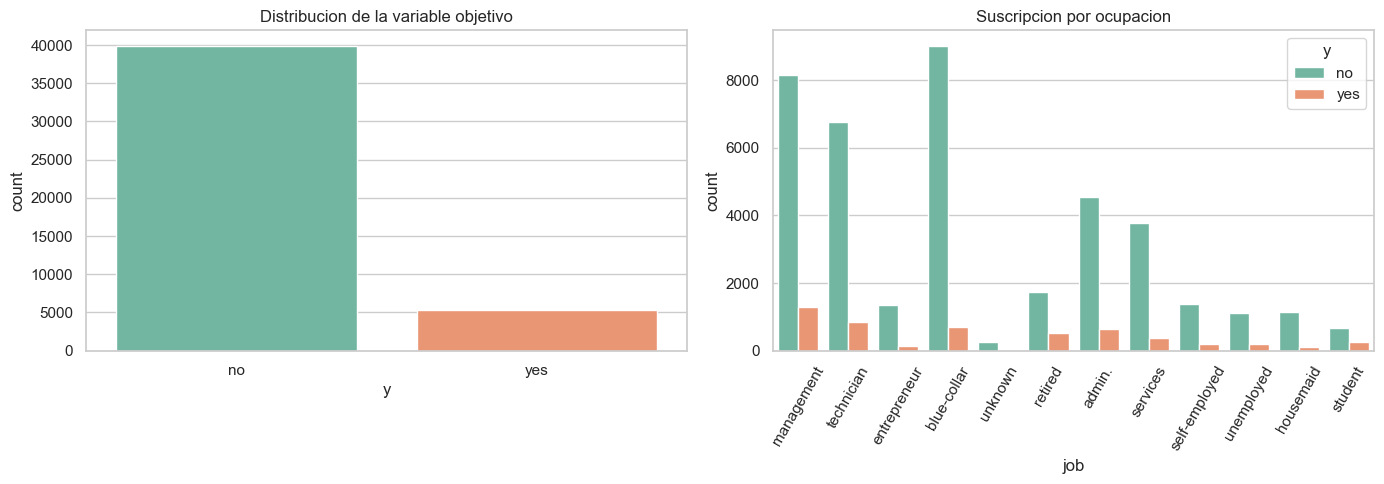

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='y', ax=axes[0], hue='y', legend=False, palette='Set2')
axes[0].set_title('Distribucion de la variable objetivo')
sns.countplot(data=df, x='job', hue='y', ax=axes[1], palette='Set2')
axes[1].set_title('Suscripcion por ocupacion')
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()
display(df.describe(include='all').T.head(25))

## 2. Analisis de las variables predictoras

Las variables predictoras describen al cliente, su situacion financiera y el historial de contacto. Analizamos por separado las variables numericas y categoricas para observar que diferencias aparecen entre quienes contrataron y quienes no.

- Los histogramas comparan la distribucion de las variables numericas según la clase objetivo.
- Los diagramas de barras muestran la tasa de suscripcion dentro de cada categoria.
- La comparacion es descriptiva: una diferencia visual no prueba que una variable sea la causa de la contratacion.

Este analisis ayuda a comprender los datos y a detectar variables que pueden aportar informacion antes de entrenar los modelos.

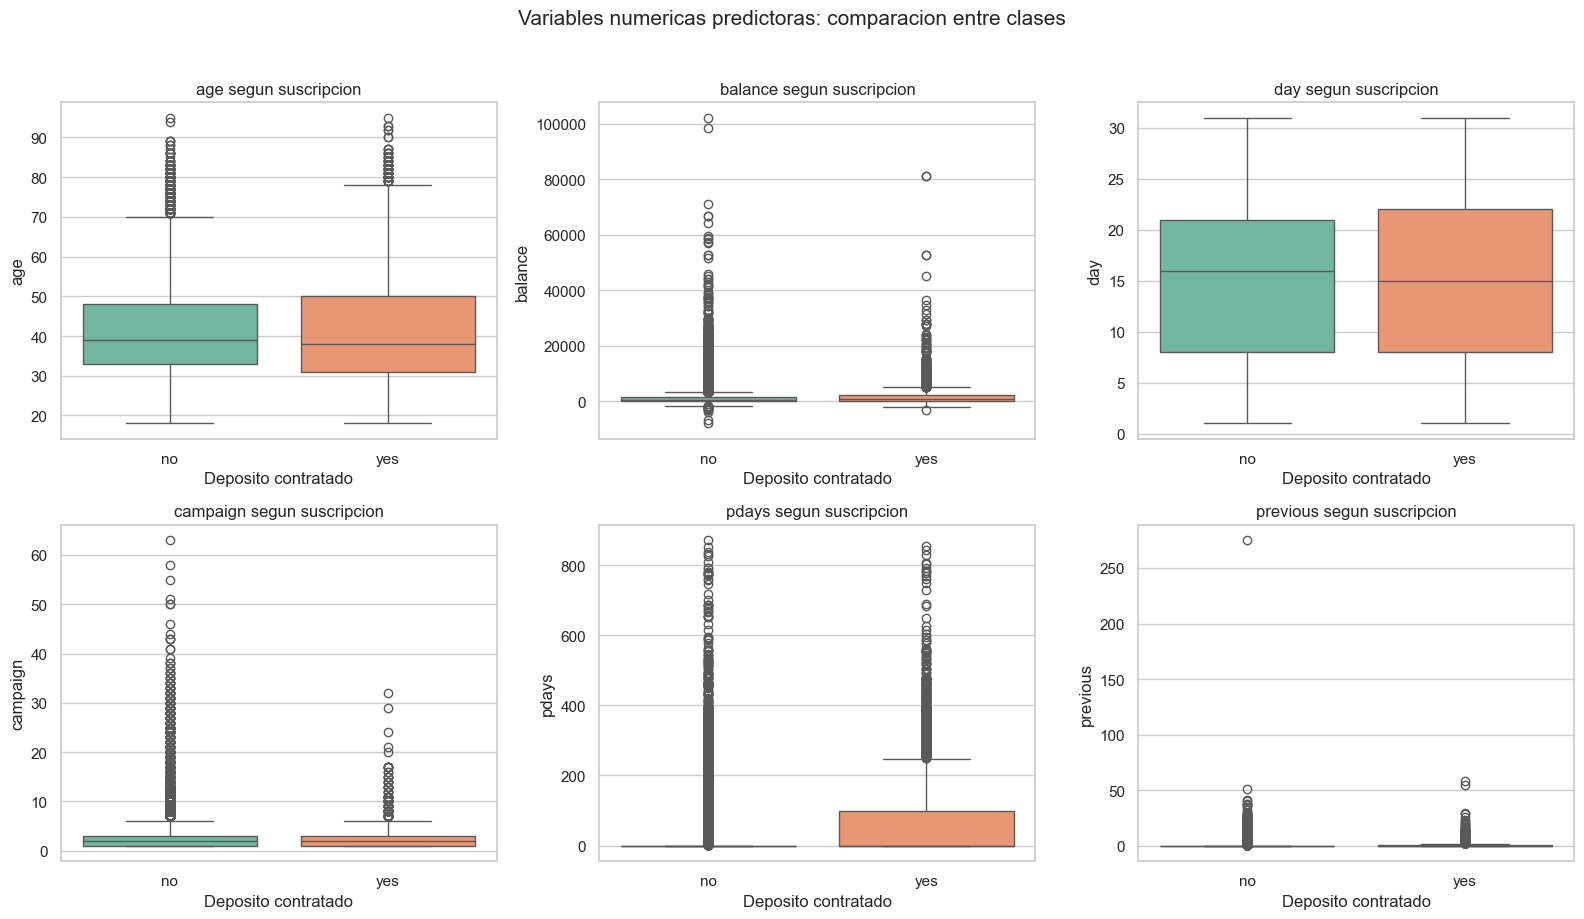

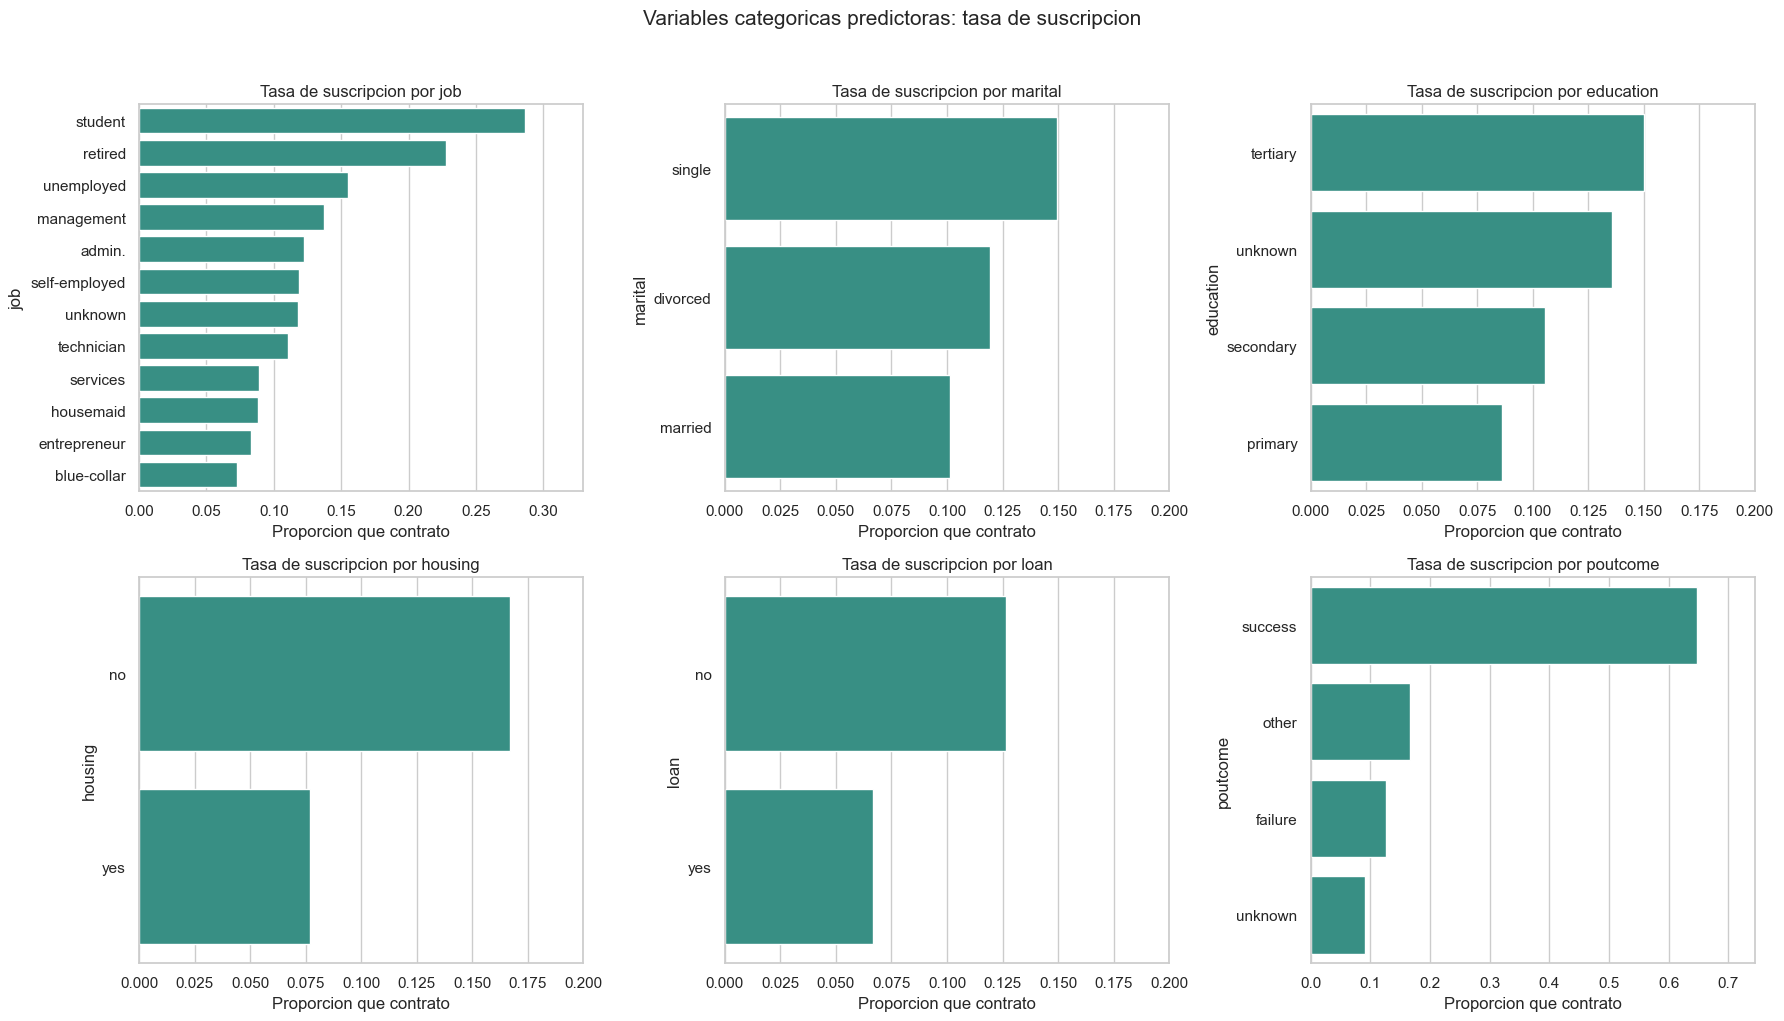

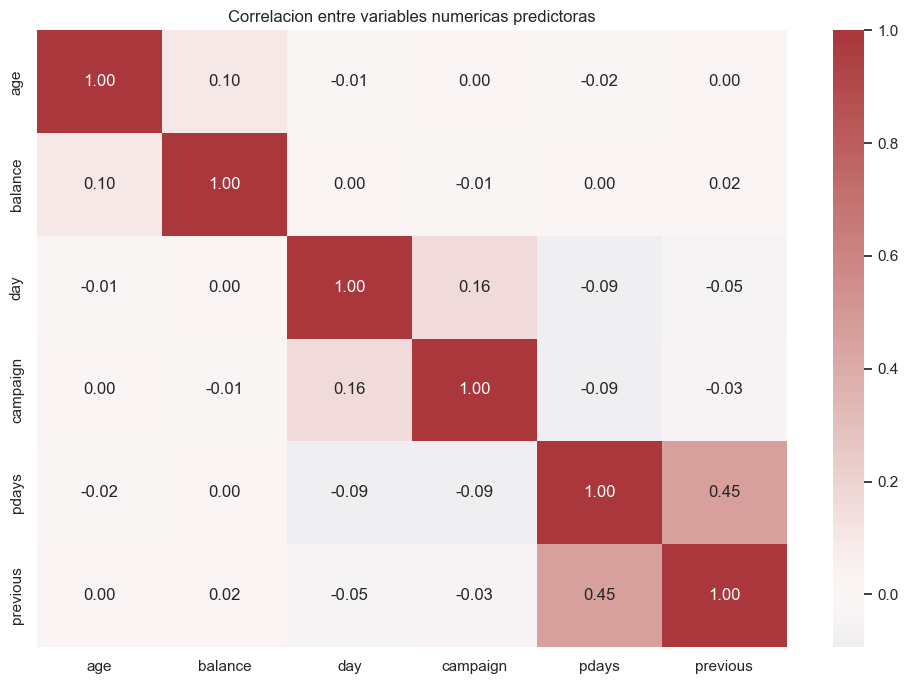

In [9]:
numeric_predictors = [column for column in df.select_dtypes(include=np.number).columns if column not in ['duration']]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.ravel(), numeric_predictors):
    sns.boxplot(data=df, x='y', y=column, hue='y', legend=False, ax=ax, palette='Set2')
    ax.set_title(f'{column} segun suscripcion')
    ax.set_xlabel('Deposito contratado')
    ax.set_ylabel(column)
plt.suptitle('Variables numericas predictoras: comparacion entre clases', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

categorical_predictors = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, column in zip(axes.ravel(), categorical_predictors):
    rates = df.groupby(column, observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, ax=ax, color='#2a9d8f')
    ax.set_title(f'Tasa de suscripcion por {column}')
    ax.set_xlabel('Proporcion que contrato')
    ax.set_ylabel(column)
    ax.set_xlim(0, max(0.2, rates.max() * 1.15))
plt.suptitle('Variables categoricas predictoras: tasa de suscripcion', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_predictors].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlacion entre variables numericas predictoras')
plt.tight_layout()
plt.show()

## 2.1. EDA profundo: calidad, desbalance y comportamiento por clase

Además de observar cada predictor, revisamos la calidad de los registros, la presencia de categorías desconocidas y el desbalance de la variable objetivo. También comparamos tasas de suscripción en combinaciones de variables para detectar patrones que podrían ser útiles para el modelado.

Registros duplicados: 0


,faltantes,categoria_unknown
age,0,0
balance,0,0
campaign,0,0
contact,0,13020
day,0,0
default,0,0
duration,0,0
education,0,1857
housing,0,0
job,0,288


,clientes,proporcion
y,,
no,39922,88.30%
yes,5289,11.70%


y                     no      yes
age      mean      40.84    41.67
         median    39.00    38.00
balance  mean    1303.71  1804.27
         median   417.00   733.00
day      mean      15.89    15.16
         median    16.00    15.00
campaign mean       2.85     2.14
         median     2.00     2.00
pdays    mean      36.42    68.70
         median    -1.00    -1.00
previous mean       0.50     1.17
         median     0.00     0.00

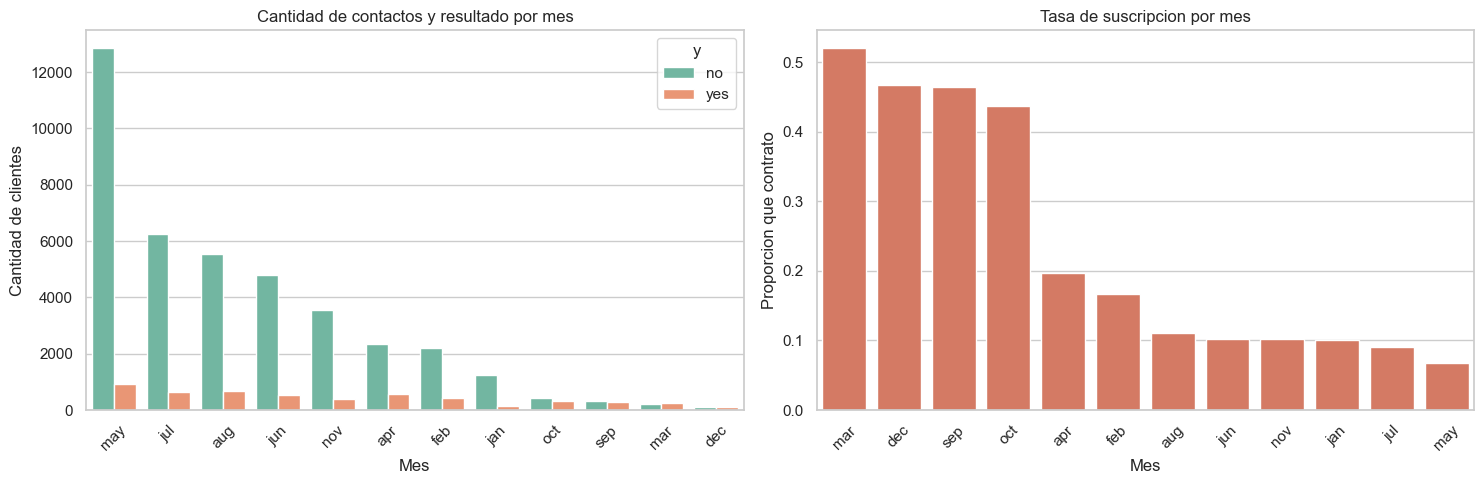

,tasa_suscripcion
poutcome,
success,64.73%
other,16.68%
failure,12.61%
unknown,9.16%


In [10]:
print('Registros duplicados:', df.duplicated().sum())
missing_summary = df.isna().sum().rename('faltantes').to_frame()
unknown_summary = (df.select_dtypes(include='object') == 'unknown').sum().sort_values(ascending=False).rename('categoria_unknown').to_frame()
quality_summary = missing_summary.join(unknown_summary, how='outer').fillna(0).astype(int)
display(quality_summary)

class_summary = df.groupby('y').size().rename('clientes').to_frame()
class_summary['proporcion'] = class_summary['clientes'] / len(df)
display(class_summary.style.format({'proporcion': '{:.2%}'}))

numeric_eda = df[numeric_predictors + ['y']].groupby('y').agg(['mean', 'median']).T.round(2)
display(numeric_eda)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x='month', hue='y', order=df['month'].value_counts().index, ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de contactos y resultado por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=45)
month_rate = df.groupby('month', observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[1], color='#e76f51')
axes[1].set_title('Tasa de suscripcion por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Proporcion que contrato')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

poutcome_rate = df.groupby('poutcome', observed=True)['y'].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False)
display(poutcome_rate.rename('tasa_suscripcion').to_frame().style.format({'tasa_suscripcion': '{:.2%}'}))

## 3. Preparacion y modelos

Se eliminan `duration` y `contact` del modelado: `duration` solo se conoce despues de realizar la llamada y produciria fuga de informacion para una prediccion operativa. Las variables categoricas se imputan y codifican con one-hot; las numericas se imputan y estandarizan dentro del pipeline.

In [4]:
X = df.drop(columns='y').copy()
y = df['y'].map({'no': 0, 'yes': 1})
X = X.drop(columns=['duration', 'contact'], errors='ignore')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_pipe, numeric_features), ('cat', categorical_pipe, categorical_features)])
models = {
    'Regresion logistica': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=2, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
}

In [5]:
results = []
fitted_models = {}
for name, estimator in models.items():
    model = Pipeline([('prep', preprocessor), ('model', estimator)])
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    fitted_models[name] = model
    results.append({'Modelo': name, 'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred), 'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred), 'ROC-AUC': roc_auc_score(y_test, proba)})
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
display(results_df.style.format({c:'{:.3f}' for c in results_df.columns if c != 'Modelo'}))

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.885,0.513,0.383,0.439,0.787
0,Regresion logistica,0.762,0.269,0.599,0.371,0.752
2,Gradient Boosting,0.894,0.657,0.201,0.308,0.784


,Modelo,ROC-AUC CV promedio,Desvio CV
1,Random Forest,0.778,0.011
2,Gradient Boosting,0.777,0.010
0,Regresion logistica,0.748,0.011


Modelo seleccionado por F1: Random Forest
              precision    recall  f1-score   support

          No       0.92      0.95      0.94      7985
          Si       0.51      0.38      0.44      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.67      0.69      9043
weighted avg       0.87      0.89      0.88      9043



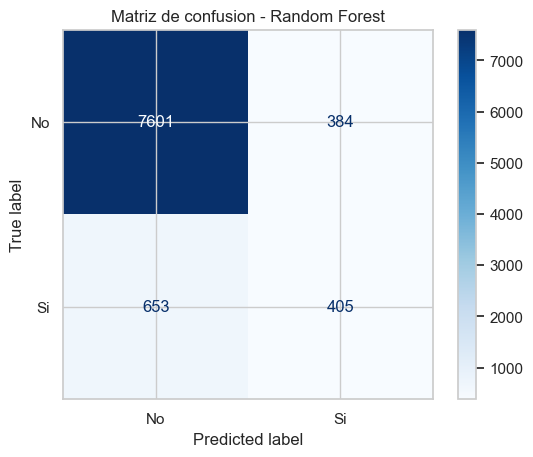

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in fitted_models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({'Modelo': name, 'ROC-AUC CV promedio': scores.mean(), 'Desvio CV': scores.std()})
display(pd.DataFrame(cv_rows).sort_values('ROC-AUC CV promedio', ascending=False).style.format({'ROC-AUC CV promedio':'{:.3f}', 'Desvio CV':'{:.3f}'}))

best_name = results_df.iloc[0]['Modelo']
best_pred = fitted_models[best_name].predict(X_test)
print(f'Modelo seleccionado por F1: {best_name}')
print(classification_report(y_test, best_pred, target_names=['No', 'Si']))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['No', 'Si'], cmap='Blues')
plt.title(f'Matriz de confusion - {best_name}')
plt.show()

## 4. Resultados obtenidos

Los resultados se comparan mediante accuracy, precision, recall, F1 y ROC-AUC.

## 4. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del modelado

El modelo recibe informacion disponible sobre un cliente y devuelve una decision: **si** o **no**, donde “si” significa que probablemente contratara el deposito a plazo. El objetivo practico es ayudar a priorizar contactos, no reemplazar la decision del cliente.

### Criterio para seleccionar los algoritmos

Se comparan tres enfoques complementarios. La regresion logistica ofrece una referencia sencilla y probabilistica. Random Forest permite capturar reglas y combinaciones entre variables. Gradient Boosting agrega arboles de forma progresiva para corregir errores. Compararlos permite evaluar si los modelos mas complejos aportan una mejora real frente a una alternativa interpretable.

**Regresion logistica.** Aunque su nombre incluye “regresion”, aqui se usa para clasificar. Calcula una probabilidad de suscripcion y la convierte en “si” o “no” usando un umbral. Es una buena referencia porque es rapida y relativamente facil de interpretar.

**Random Forest.** Combina muchos arboles de decision. Cada arbol analiza reglas diferentes sobre edad, empleo, saldo, historial y campaña; la respuesta final surge de combinar esas decisiones. Puede detectar combinaciones de variables que una regla simple no captura.

**Gradient Boosting.** Genera arboles uno despues de otro. Cada nuevo arbol presta atencion a los clientes que fueron clasificados incorrectamente antes. Puede lograr buen desempeño, aunque sus decisiones son mas dificiles de resumir en una sola regla.

### Criterios de evaluacion

- **Accuracy:** porcentaje total de aciertos. Puede ser engañosa cuando hay muchos mas “no” que “si”.
- **Precision:** de los clientes que el modelo marco como posibles interesados, cuantos realmente contrataron.
- **Recall:** de todos los clientes que realmente contrataron, cuantos fueron encontrados por el modelo.
- **F1:** combina precision y recall en un unico valor. Es util cuando ambas cosas importan.
- **ROC-AUC:** mide que tan bien ordena el modelo a los clientes mas propensos antes de elegir un punto de corte. Un valor de 0,5 equivale aproximadamente al azar y un valor mayor indica mejor separacion.

### Interpretacion de resultados

La matriz separa aciertos y errores. Un **falso positivo** es contactar a alguien que finalmente no contrata; un **falso negativo** es no priorizar a alguien que si habria contratado. La importancia de cada error depende del costo de la campaña y de la capacidad del equipo comercial.

Se excluye `duration` porque solo se conoce despues de la llamada. Usarla haria que el modelo pareciera mejor de lo que seria en una campaña real: estaria usando informacion del futuro.

**Decision final:** no siempre conviene elegir el modelo con mayor accuracy. La seleccion debe considerar F1, ROC-AUC, precision, recall y el costo real de los falsos positivos y falsos negativos.